In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets
X['Target'] = y

# CDC Diabetes Prediction — XGBoost & Neural Network

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Separate features and target
X_data = cdc_diabetes_health_indicators.data.features
y_data = cdc_diabetes_health_indicators.data.targets.values.ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

# Scale features (needed for Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Class distribution — 0: {(y_data==0).sum()}, 1: {(y_data==1).sum()}")

Train size: (202944, 22), Test size: (50736, 22)
Class distribution — 0: 218334, 1: 35346


## XGBoost

In [5]:
import xgboost as xgb

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=neg / pos,   # handles class imbalance
    eval_metric='auc',
    random_state=42,
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

y_pred_xgb  = xgb_model.predict(X_test)
y_prob_xgb  = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Results ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

[0]	validation_0-auc:1.00000


c:\Users\Padmakar Koushik\CDC_Diabetes_Prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:26:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-auc:1.00000
[100]	validation_0-auc:1.00000
[150]	validation_0-auc:1.00000
[199]	validation_0-auc:1.00000

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     43667
           1       1.00      1.00      1.00      7069

    accuracy                           1.00     50736
   macro avg       1.00      1.00      1.00     50736
weighted avg       1.00      1.00      1.00     50736

ROC-AUC: 1.0000


AttributeError: Rectangle.set() got an unexpected keyword argument 'figsize'

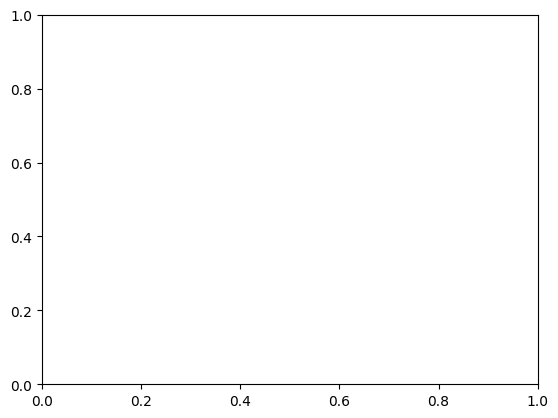

In [6]:
# XGBoost feature importance
xgb.plot_importance(xgb_model, max_num_features=15, figsize=(10, 6))
plt.title("XGBoost — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

## Neural Network (MLP)

In [7]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=True
)

mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Neural Network Results ===")
print(classification_report(y_test, y_pred_mlp))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_mlp):.4f}")

Iteration 1, loss = 0.01375409
Validation score: 1.000000
Iteration 2, loss = 0.00005408
Validation score: 1.000000
Iteration 3, loss = 0.00004791
Validation score: 1.000000
Iteration 4, loss = 0.00004567
Validation score: 1.000000
Iteration 5, loss = 0.00004391
Validation score: 1.000000
Iteration 6, loss = 0.00004199
Validation score: 1.000000
Iteration 7, loss = 0.00003965
Validation score: 1.000000
Iteration 8, loss = 0.00003675
Validation score: 1.000000
Iteration 9, loss = 0.00003318
Validation score: 1.000000
Iteration 10, loss = 0.00002892
Validation score: 1.000000
Iteration 11, loss = 0.00002411
Validation score: 1.000000
Iteration 12, loss = 0.00001906
Validation score: 1.000000
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

=== Neural Network Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     43667
           1       1.00      1.00      1.00      7069

    accuracy

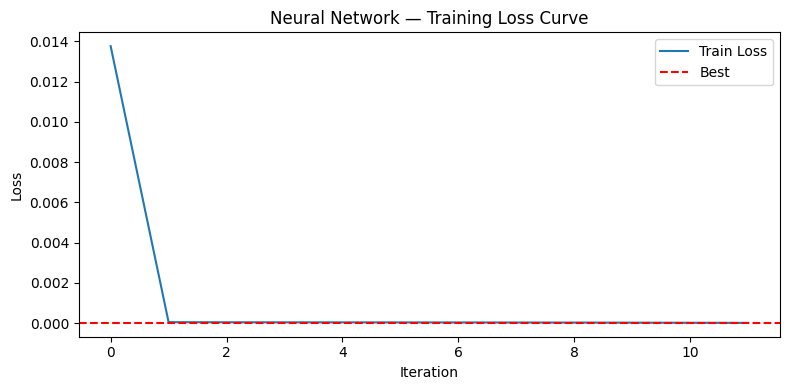

In [8]:
# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(mlp_model.loss_curve_, label='Train Loss')
if mlp_model.best_validation_score_:
    plt.axhline(y=min(mlp_model.loss_curve_), color='r', linestyle='--', label='Best')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Neural Network — Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()

## Model Comparison

TypeError: unsupported operand type(s) for +: 'Axes' and 'Axes'

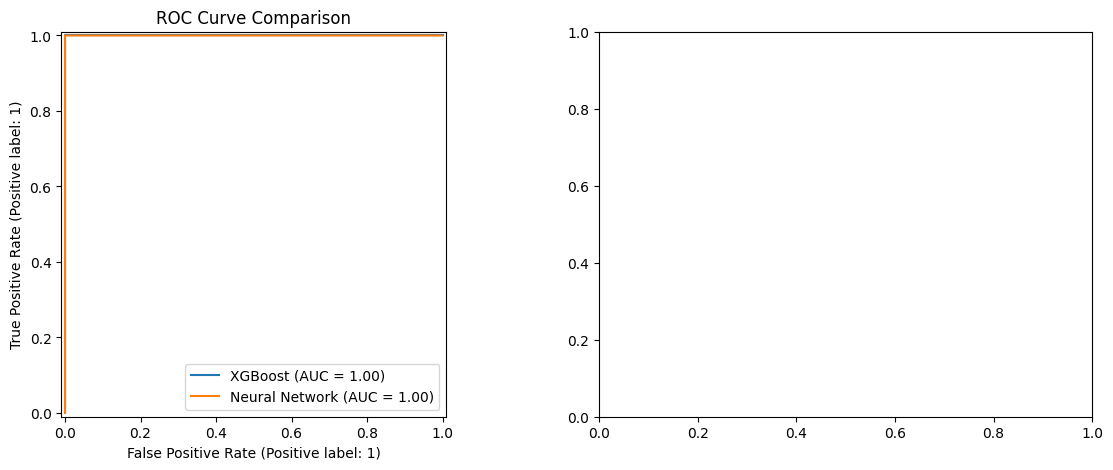

In [9]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_prob_mlp, name="Neural Network", ax=axes[0])
axes[0].set_title("ROC Curve Comparison")

# Confusion matrices side by side
for ax, y_pred, title in zip(
    axes[1:] + [axes[1]],
    [y_pred_xgb, y_pred_mlp],
    ["XGBoost", "Neural Network"]
):
    pass

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, title in zip(axes2, [y_pred_xgb, y_pred_mlp], ["XGBoost", "Neural Network"]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"{title} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("\n=== AUC-ROC Summary ===")
print(f"XGBoost:        {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"Neural Network: {roc_auc_score(y_test, y_prob_mlp):.4f}")